## Profit Prediction ON ML

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Step - 1 >>> Data Collection

In [164]:
df = pd.read_csv(r'C:\7M\Machine Learning\Data\Row Datasets\50_Startups.csv')

In [165]:
df.shape

(50, 5)

#### Step - 2 >>> Data cleaning

In [166]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [167]:
df.duplicated().sum()

np.int64(0)

In [168]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

#### Step - 3 EDA (Exploratory data analysis)


In [169]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [170]:
cm = df.corr(numeric_only=True)
cm

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

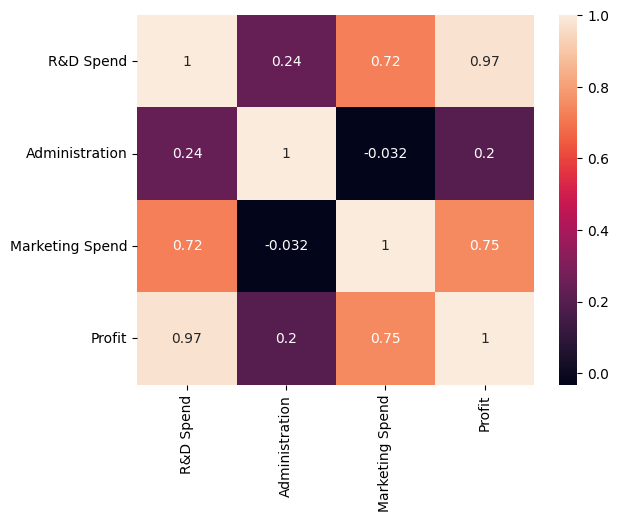

In [171]:
sns.heatmap(cm, annot=True)

In [172]:
# R&D and Profit has strong positive correlation

<Axes: xlabel='R&D Spend', ylabel='Profit'>

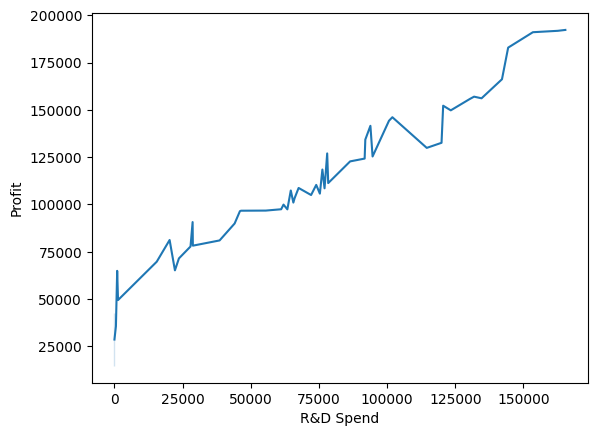

In [173]:
sns.lineplot(x='R&D Spend', y='Profit', data=df)

In [174]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

<Axes: xlabel='R&D Spend', ylabel='Profit'>

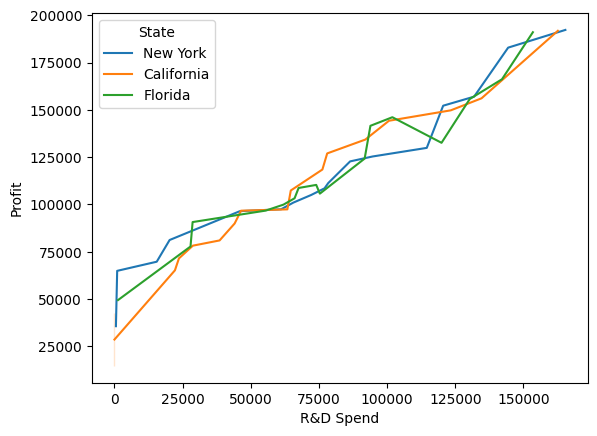

In [175]:
sns.lineplot(data=df, x='R&D Spend', y='Profit', hue='State')

<Axes: xlabel='State', ylabel='Profit'>

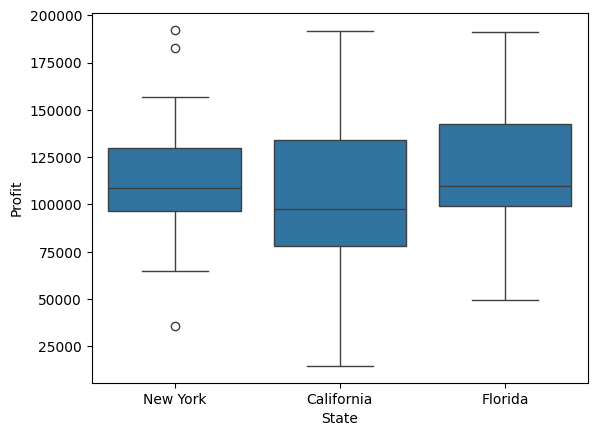

In [176]:
sns.boxplot(data=df, x='State', y='Profit')

<Axes: xlabel='Marketing Spend', ylabel='Profit'>

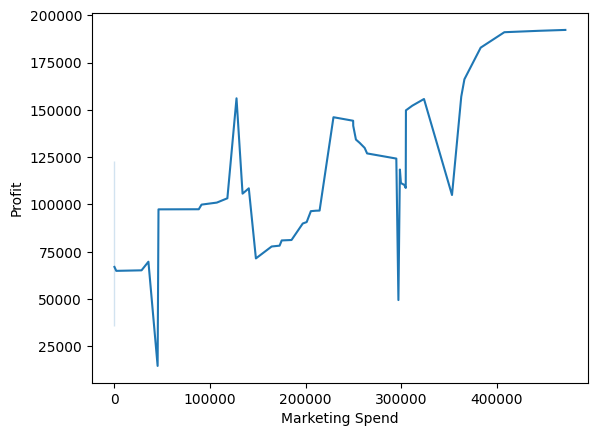

In [177]:
sns.lineplot(data=df, x='Marketing Spend', y='Profit')

In [178]:
# X,y
# encoding
# scaling
# CV

X = df.drop('Profit', axis=1)
y = df['Profit']

In [179]:
X.head()

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida


In [180]:
y.head()

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64

In [181]:
# encoding

from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder(sparse_output=False)
X[oh.get_feature_names_out()] = oh.fit_transform(X[['State']])

In [182]:
X.drop(columns=oh.feature_names_in_, inplace=True)

In [183]:
X.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0.0,0.0,1.0
1,162597.70,151377.59,443898.53,1.0,0.0,0.0
2,153441.51,101145.55,407934.54,0.0,1.0,0.0
3,144372.41,118671.85,383199.62,0.0,0.0,1.0
4,142107.34,91391.77,366168.42,0.0,1.0,0.0


In [184]:
# scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X[['R&D Spend', 'Administration', 'Marketing Spend']] = sc.fit_transform(
    X[['R&D Spend', 'Administration', 'Marketing Spend']])

In [185]:
X.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,2.016411,0.560753,2.153943,0.0,0.0,1.0
1,1.955860,1.082807,1.923600,1.0,0.0,0.0
2,1.754364,-0.728257,1.626528,0.0,1.0,0.0
3,1.554784,-0.096365,1.422210,0.0,0.0,1.0
4,1.504937,-1.079919,1.281528,0.0,1.0,0.0


In [186]:
# CV

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [187]:
X_train.shape

(40, 6)

In [188]:
X_test.shape

(10, 6)

In [189]:
y_train.shape

(40,)

In [190]:
y_test.shape

(10,)

In [191]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [192]:
lr.coef_

array([36608.56770003, -1907.9151244 ,  3614.33667765,  -315.26025537,
         623.53275078,  -308.2724954 ])

In [193]:
lr.intercept_

np.float64(111688.85670089848)

In [194]:
lr.score(X_test, y_test)*100

89.87266414319836

In [195]:
# Find error
# MAE
# RMSE
# R2

y_pred = lr.predict(X_test)

In [196]:
y_pred

array([126362.87908252,  84608.45383643,  99677.49425155,  46357.46068582,
       128750.48288497,  50912.41741905, 109741.350327  , 100643.24281644,
        97599.275746  , 113097.42524437])

In [197]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)**0.5))
print('R2:', r2_score(y_test, y_pred) * 100)

MAE: 6961.47781327556
RMSE: 95.16279379830024
R2: 89.87266414319836


In [198]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(root_mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred) * 100)

MAE: 6961.47781327556
RMSE: 95.16279379830024
R2: 89.87266414319836


In [199]:
# Step 7 >>> Model Deployment

In [200]:
import pickle

In [ ]:
with open('model', 'wb') as f:
    pickle.dump(lr, f)

In [ ]:
with open('encoder', 'wb') as f:
    pickle.dump(oh, f)

In [ ]:
with open('scaler', 'wb') as f:
    pickle.dump(sc, f)

In [212]:
newdf = pd.DataFrame({
    'R&D Spend': [75328.87],
    'Administration': [144135.98],
    'Marketing Spend': [134050.07],
    'State': ['Florida']
})
newdf

,R&D Spend,Administration,Marketing Spend,State
0,75328.87,144135.98,134050.07,Florida


In [213]:
newdf[oh.get_feature_names_out()] = oh.transform(newdf[['State']])

In [214]:
newdf.drop(columns=oh.feature_names_in_, inplace=True)

In [215]:
newdf

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,75328.87,144135.98,134050.07,0.0,1.0,0.0


In [216]:
newdf[['R&D Spend', 'Administration', 'Marketing Spend']] = sc.transform(newdf[['R&D Spend', 'Administration', 'Marketing Spend']])

In [217]:
newdf

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,0.03537,0.821718,-0.635835,0.0,1.0,0.0


In [221]:
lr.predict(newdf)

array([109741.350327])